# Vacuum simulation

## 1. Delete water using `Modeller`
Delete waters from `data/ala2.pdb`

In [1]:
from openmm.app import Modeller, PDBFile
from src.param import param_unbiased_vaccuum

p = param_unbiased_vaccuum()
pdb_file = p.working_dir / "ala2_vac.pdb"

model_system = False
if model_system:
    pdb = PDBFile(p.pdb_file)
    modeller = Modeller(pdb.topology, pdb.positions)
    modeller.deleteWater()  # removes HOH/WAT residues
    # if you also added counter-ions, drop them too:
    ions = [r for r in modeller.topology.residues() if r.name in ("NA", "CL", "K")]
    modeller.delete(ions)
    modeller.topology.setPeriodicBoxVectors(None)  # optional: discard the box entirely

    top = modeller.topology
    vac_positions = modeller.positions

    with open(pdb_file, "w") as f:
        PDBFile.writeFile(top, vac_positions, f, keepIds=True)
else:
    vac_pdb = PDBFile(str(pdb_file))
    top = vac_pdb.topology
    vac_positions = vac_pdb.positions

## 2. Perform simulations and write dihedral & feature data

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import openmm as mm
from openmm.app import Simulation, ForceField, HBonds, NoCutoff

from src.data import simulation_data
from src.util import state_data_reporter, hdf5_reporter
from src.util import print_platform


def create_system(forcefield, topology):
    return forcefield.createSystem(
        topology,
        nonbondedMethod=NoCutoff,  # the "turn off PBC" switch
        constraints=HBonds,
        removeCMMotion=True,  # keeps the COM from drifting
    )


step_start = 9914  #  June 26-July 3, 2026
num_steps = 15_000
do_simulation = False

if do_simulation:
    forcefield = ForceField("amber99sb.xml")
    system = create_system(forcefield, top)  # <- cleaned topology, not pdb.topology

    for step in range(step_start, num_steps):
        print(f"starting simulation {step} of {num_steps}")

        # start positions
        if step == 0:
            start_positions = vac_positions  # <- cleaned positions
        else:
            if step == step_start:
                sd = simulation_data(p, subdir=(step - 1))
            start_positions = sd.final_positions
        assert (
            type(start_positions) == mm.unit.quantity.Quantity
        ), f"ERROR: {type(start_positions) = } in step {step}"

        # new 'sd' object for present simulation files
        sd = simulation_data(p, subdir=step)
        outfile = str(sd.files["outfile"])
        h5file = str(sd.files["h5file"])

        # each step requires new integrator, simulation object
        integrator = mm.LangevinIntegrator(p.temperature, p.friction_coeff, p.timestep)
        simulation = Simulation(top, system, integrator)  # <- top, not pdb.topology
        print_platform(simulation)

        simulation.context.setPositions(start_positions)
        if step == 0:
            simulation.minimizeEnergy()  # minimize once, at the start
        simulation.context.setVelocitiesToTemperature(p.temperature)

        sdr = state_data_reporter(outfile, p.report_interval)
        hdr = hdf5_reporter(h5file, p.report_interval)
        simulation.reporters.append(sdr)
        simulation.reporters.append(hdr)
        simulation.step(round(p.simulation_time / p.timestep))

        for reporter in simulation.reporters:
            if hasattr(reporter, "close"):
                reporter.close()

        # save 'final_positions'
        r = simulation.context.getState(getPositions=True).getPositions()
        sd.save_and_assign_objects({"final_positions": r})

        # calculate and save 'dihedrals', 'features' from 'h5file'
        sd.save_feature_data(recalculate=True)

## 3. Gather data from steps into master files

* Concatenate `dihedrals`, `features` arrays from each step
* Write combined data files to `p.working_dir`

In [3]:
from src.data import gather_feature_data
from src.grid2d import hist2d
from src.dataclass import data_class, DataClass
from src.plots import plot_dihedrals_hist2d

gather_data = False
if gather_data:
    sd = gather_feature_data(p, num_steps)  # streams per-step files into memmaps
else:
    sd = simulation_data(p)

compute_pdf = False
if compute_pdf:
    theta = np.linspace(-np.pi, np.pi, 100)
    pdf = DataClass(x=theta, y=theta, p=hist2d(theta, theta, sd.dihedrals))
    dihedrals_shape = sd.dihedrals.shape
    features_shape = sd.features.shape
else:
    pdf = None
    dihedrals_shape = (15000000, 2)
    features_shape = (15000000, 45)

print(f"{dihedrals_shape = }")
print(f"{features_shape = }")

plot = False
if plot:
    pdf = data_class(sd.working_dir, "dihedrals_pdf", pdf)

    fig, ax = plt.subplots(1, 1, figsize=(4, 3))
    plot_dihedrals_hist2d(fig, ax, pdf)
    fig.savefig("notes/figures/unbiased-dih-hist2d-vac.png", bbox_inches="tight")

dihedrals_shape = (15000000, 2)
features_shape = (15000000, 45)


## 4. Train SRV

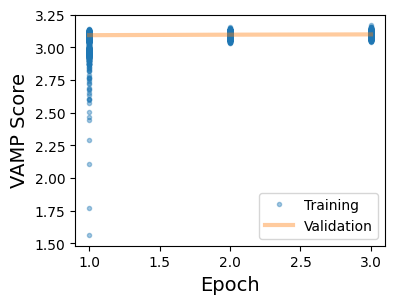

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
from src.param import param_unbiased_vaccuum
from src.data import simulation_data
from src.dataset import TrajectoryDataset, data_loaders
from src.vampnet import vampnet

p = param_unbiased_vaccuum()
sd = simulation_data(p, mmap_mode="r")
dataset = TrajectoryDataset(sd.features, lagframes=sd.lagframes)
num_epochs = 3

train = False
if train:
    vn = vampnet(p, weighted=False)
    vn.fit(  # num_workers, prefetch_factor only make sense for mmap_mode="r"
        *data_loaders(dataset, p.frac_test, num_workers=0, prefetch_factor=4),
        num_epochs=num_epochs,
        progress=tqdm,
    )
    sd.save_and_assign_objects({"vampnet": vn})

fig, ax = plt.subplots(1, 1, figsize=(4, 3))
ax.plot(*sd.vampnet.train_scores.T, ".", alpha=0.4, label="Training")
ax.plot(*sd.vampnet.test_scores.T, "-", linewidth=3, alpha=0.4, label="Validation")
ax.set_xlabel("Epoch", fontsize=14)
ax.set_ylabel("VAMP Score", fontsize=14)
ax.legend()
fig.savefig("notes/figures/vampnet-vacuum.png", bbox_inches="tight")

In [2]:
import psutil

print(f"Available: {psutil.virtual_memory().available / 1e9:.2f} GB")
print(type(sd.features))  # numpy.memmap  -> mmap path
print(type(dataset.x))  # numpy.memmap  -> slice is still a memmap
print(sd.features.flags["OWNDATA"])  # False for a memmap-backed view

Available: 1.74 GB
<class 'numpy.memmap'>
<class 'numpy.memmap'>
False


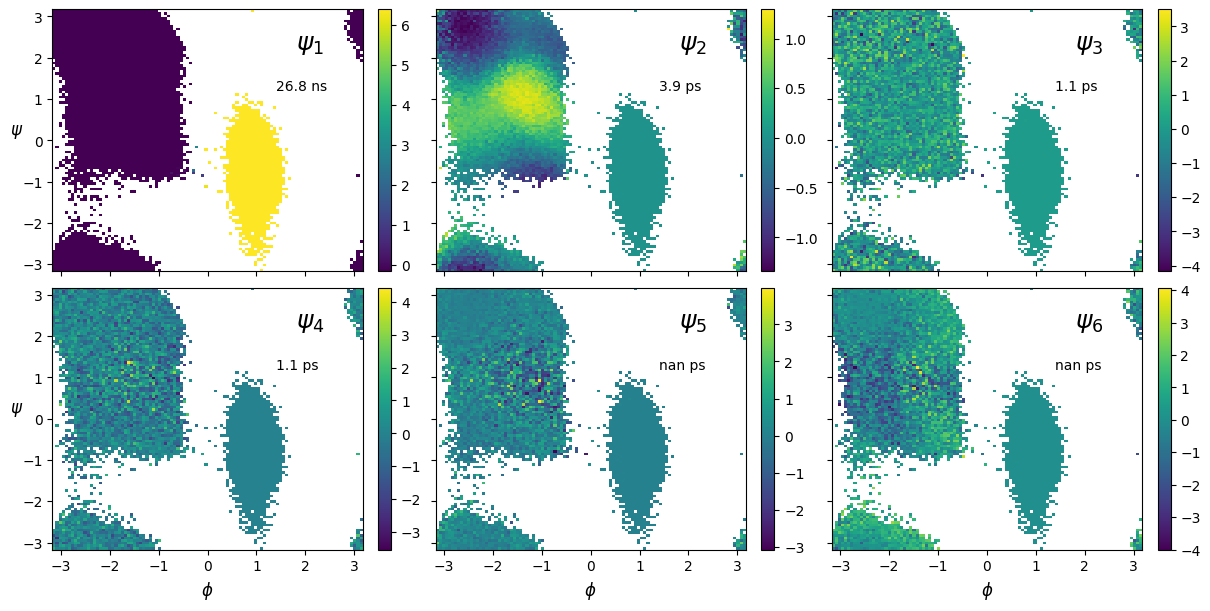

In [3]:
from src.vampnet import SRV
from src.plots import plot_eigfuncs

calculate = False
if calculate:
    srv = SRV(sd.vampnet.net, sd.lagtime).fit(dataset)
    sd.save_eigen_data(srv)
    sd.save_grid_data(srv, num_points=100)

fig, axs = plt.subplots(
    2, 3, figsize=(12, 6), sharex=True, sharey=True, constrained_layout=True
)
plot_eigfuncs(fig, axs, sd.theta_grid, sd.psi_grid, sd.timescales)

## 5. Explore CV dataset and create histogram

In [ ]:
from scipy import stats
from src.grid2d import hist2d

stats.describe(sd.cvs, axis=0)

DescribeResult(nobs=np.int64(15000000), minmax=(array([-0.15785453, -1.49440853]), array([6.38425712, 1.78720063])), mean=array([-1.04475265e-08, -4.02205401e-09]), variance=array([0.99998924, 0.99999249]), skewness=array([ 6.22764339, -0.10170845]), kurtosis=array([36.78356346, -1.75883507]))


| Statistic | ψ₁ (col 0) | ψ₂ (col 1) | Reference (Gaussian) |
|---|---:|---:|---:|
| N | 15,000,000 | 15,000,000 | — |
| min | −0.1579 | −1.4944 | — |
| max | +6.3843 | +1.7872 | — |
| mean | −1.04 × 10⁻⁸ | −4.02 × 10⁻⁹ | 0 |
| variance | 0.99999 | 0.99999 | 1 |
| skewness | **+6.228** | −0.102 | 0 |
| excess kurtosis | **+36.78** | −1.759 | 0 |

Mean and variance confirm the SRV normalization holds to float precision for both — nothing to correct.

### ψ₁ — heavy one-sided tail, a rarely-visited second state

Skew +6.23 and excess kurtosis +36.8 are both enormous and both positive. This is the quantitative form of the min/max we already flagged: the density is a sharp pile near the lower bound (~−0.13) with a long, thin tail reaching out to +6.4, and essentially no left tail. The distribution is one dominant state plus rare, far excursions into a second — exactly what a slow φ sign-flip mode looks like when the transitioned state is seldom occupied.

The consequence for your ACF is unchanged and now quantified: the long-lag decay of ψ₁'s ACF is defined by a small number of independent crossing events buried under that tail. A single-exponential fit here is statistically fragile, and "too few transitions" remains a live competing explanation for any non-single-exponential behaviour — to be ruled out *before* you attribute anything to featurization.

### ψ₂ — strongly bimodal, well-sampled

* skew −0.10 is effectively symmetric
* informative number is excess kurtosis −1.76. The theoretical floor on excess kurtosis is −2 (attained only by a pure two-point distribution), so −1.76 sits close to that floor — this is a strongly **bimodal** coordinate

Both predictions from the raw ranges held: ψ₁'s heavy right tail and ψ₂'s platykurtic bimodality are now on record. These are static equilibrium-density descriptors — good for judging sampling and Gaussianity, but the single-exponential question is the separate time-domain measurement. Pull up the ACF code when ready.

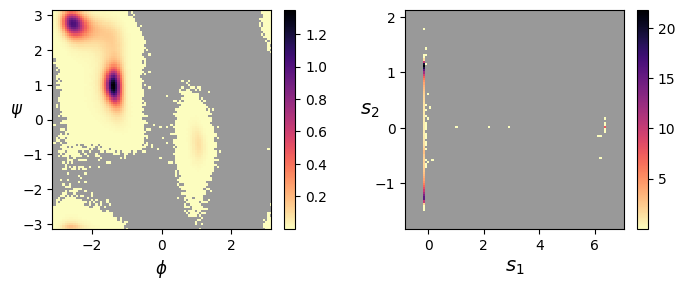

In [28]:
from src.dataclass import DataClass
from src.grid2d import ranges_data, grid1d_from_range, hist2d, grid_norm
from src.plots import plot_dihedrals_hist2d, plot_cvs_hist2d

calculate = False
if calculate:
    ranges = ranges_data(sd.cvs, pad=0.10)
    ranges = np.round(ranges, 1)  # -> [[-0.8, 7.0], [-1.8, 2.1]]
    x = grid1d_from_range(ranges[0])
    y = grid1d_from_range(ranges[1])
    pdf = DataClass(x=x, y=y, p=hist2d(x, y, sd.cvs, density=True))
    pdf.savez("data/vacuum/cvs_pdf.npz")

    x = sd.theta_grid
    y = sd.theta_grid
    pdf = DataClass(x=x, y=y, p=hist2d(x, y, sd.dihedrals, density=True))
    pdf.savez("data/vacuum/dihedrals_pdf.npz")

fig, axs = plt.subplots(1, 2, figsize=(7, 3))
plot_dihedrals_hist2d(fig, axs[0], sd.dihedrals_pdf)
plot_cvs_hist2d(fig, axs[1], sd.cvs_pdf)
fig.tight_layout()